<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200"/>
</p></center>

<center><font size=10>AI Agents for Business Applications</center></font>
<center><font size=6>Advanced Agentic AI Solutions</center></font>
<center><font size=6>Week 2 - Testing and Evaluation of Agentic Systems</center></font>

<center><p float="center">
  <img src="https://images.pexels.com/photos/6170458/pexels-photo-6170458.jpeg" width="640"/>
</p></center>

<center><font size=6>AI-powered Shipment Disruption Router
</center></font>

# **Problem Statement**

## **Business Context**

A mid-sized freight and logistics company manages hundreds of daily shipments across domestic and international lanes. When disruptions occur — weather delays, customs holds, carrier failures, warehouse capacity breaches — the current process requires a dispatcher to manually review each incident, decide whether to reroute, hold, or escalate, and then notify the relevant downstream teams (warehouse, carrier, customer).

This manual loop introduces **2-4 hour decision latency per incident**, causes **misrouted shipments due to inconsistent dispatcher judgment**, and provides **no clear audit trail for compliance review**.

As shipment volumes grow, this manual process becomes difficult to scale. Operational teams must handle increasing disruption events while maintaining strict service-level agreements (SLAs). The lack of standardized decision support leads to delays, operational inefficiencies, and a higher risk of SLA breaches.

## **Objective**

The goal is to build an **AI-powered Shipment Disruption Router**

A multi-agent system that can automatically analyze disruption events and generate policy-grounded operational decisions.

The system will:

- **(a) Classify** the disruption type and severity based on the incoming event details  
- **(b) Retrieve** the applicable rerouting or mitigation policy from a logistics rulebook  
- **(c) Generate** a structured decision and action plan grounded in the retrieved policy  
- **(d) Validate** the decision before it is acted upon  
- **(e) Escalate** ambiguous or high-risk cases to a human dispatcher  

Every decision step will be **traced via LangSmith** for latency monitoring, audit, and continuous improvement.


**Primary Success Metrics (KPIs)**

- Decision latency per incident ↓
- Correct routing decision rate (vs. ground truth) ↑
- Escalation rate due to policy violations / low confidence ↓
- SLA breach rate ↓

### **Data Description**

| Column | Description |
|------|-------------|
| Order Id | Unique identifier for each test case or order used to simulate shipping scenarios. |
| Type | Payment or transaction type associated with the order (e.g., Debit). |
| Days for shipping (real) | Actual number of days taken to deliver the order. |
| Days for shipment (scheduled) | Planned or scheduled number of days allocated for shipment. |
| Delivery Status | Final delivery outcome such as on-time, late delivery, or canceled shipment. |
| Late_delivery_risk | Binary indicator (0 or 1) showing whether the order has a risk of late delivery. |
| Order Status | Current status of the order such as COMPLETE or CANCELED. |
| Shipping Mode | Mode of shipping used (e.g., Standard Class, Second Class, First Class). |
| Order Region | Geographic region where the order was placed. |
| Order City | City from which the order originated or was processed. |
| Order Country | Country where the order was placed. |
| Customer Segment | Customer category such as Consumer or Corporate. |
| Category Name | Product category associated with the order (e.g., Electronics, Books). |
| Sales | Total sales amount for the order item(s). |
| Order Item Quantity | Number of items included in the order. |
| delay_gap | Difference between actual shipping days and scheduled shipping days (real − scheduled). Positive values indicate delay, negative values indicate faster delivery. |
| decision_expected | Expected operational decision or action (e.g., monitor, reroute, expedite, escalate to human). |
| expected_policies | Policy IDs that should be triggered or applied for the given scenario. Multiple policies may be separated by `|`. |

# **Solution Approach**

## A) Multi-Agent Architecture (LangGraph)

We will implement a multi-agent workflow as a LangGraph state machine with the following agents:


1. Intake Agent

*  Normalizes the disruption event (field validation, missing value handling)
*  Extracts urgency signals (SLA pressure, cargo sensitivity, severity score)
*  Passes structured context to downstream agents


2. Classifier Agent

*  Predicts disruption type and severity from event fields
*  Produces confidence scores
*  Routes to human escalation if confidence falls below threshold


3. Policy Retrieval Agent (Grounding)

*  Determines which policy sections are relevant (weather protocol? carrier SLA? hazmat handling?)
*  Executes targeted lookup against a synthetic logistics rulebook
*  Returns grounded evidence chunks with policy citations


4. Router Agent

*  Generates a structured routing decision (reroute, hold, expedite, escalate_human)
*  Decision is grounded strictly in retrieved policy evidence
*  Produces a structured action plan with citation references


5. Auditor Agent (Validation)

*  Skeptical reviewer that checks:
    *  Schema compliance — decision fields are valid and complete
    *  Policy compliance — decision aligns with retrieved policy, no invented procedures
    *  Conflict detection — decision does not contradict cargo type or SLA constraints
*  Can force re-retrieval, revise decision, or escalate to human


6. Human-in-the-Loop Node

*  Triggered when: severity is critical, confidence is low, or AuditorAgent flags a violation
*  Presents full decision context and trace to dispatcher
*  Captures dispatcher override or approval as structured feedback

## B) Grounding + Validation Strategy

We treat grounding as a first-class pipeline step, not an afterthought:

*  Policy retrieval happens before decision generation (retrieve-then-decide, not decide-then-justify)
*  AuditorAgent performs claim-to-policy matching
*  No decision is passed downstream without a valid policy citation

## C) Integration + System + Multi-Agent Testing

*  Integration tests — controlled handoff tests between each agent pair with fixed inputs
*  System tests — end-to-end runs across all 5 disruption types and 4 severity levels
*  Per-agent tests — accuracy (vs. decision_expected), latency benchmarks, robustness under adversarial/malformed inputs

## D) LangSmith Instrumentation

We will use LangSmith for:

*  Tracing every agent step (classify → retrieve → route → audit → HITL)
*  Capturing per-node latency for benchmarking
*  Comparing runs across prompt and policy changes

## Flow Diagram of the project

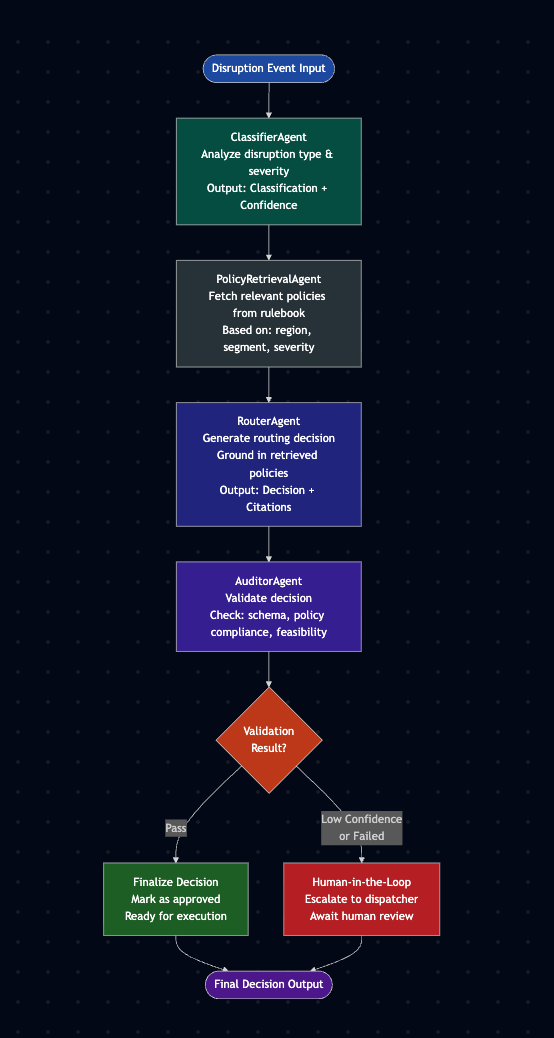

# **Installing and Importing the Necessary Libraries**

In [ ]:
# Install the required packages
!pip install -q langchain==1.2.10 langchain_community langchain-openai langgraph==1.0.9 langsmith==0.7.7 pandas==2.2.2 numpy==2.0.2 python-dotenv==1.2.1 chromadb tiktoken==0.12.0 sentence_transformers==5.2.3

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [ ]:
# Import core libraries
import os
import json
import re
import pandas as pd
import numpy as np
from typing import TypedDict, Annotated, List, Dict, Any, Optional, Tuple
from datetime import datetime, timedelta
import operator
import statistics
from datetime import datetime
from IPython.display import display, Image, Markdown

# LangChain imports
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser, StrOutputParser
from pydantic import BaseModel, Field

# Hugging face embedding imports

from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

# LangGraph imports
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

# LangSmith setup
from langsmith import Client
from langsmith.evaluation import evaluate

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# **LLM and Agent Observability Setup**

## LangSmith Setup

In a multi-agent system, multiple agents and tools may run in sequence, passing state and intermediate results between them. As the workflow grows in complexity, it becomes challenging to understand:

- why a particular routing decision was made,
- which documents or chunks were retrieved,
- where an incorrect or unexpected output originated,

and more.

LangSmith provides observability for agentic AI workflows by logging:

- the end-to-end execution flow
- all tool and agent calls
- intermediate inputs and outputs
- key performance metrics

With LangSmith, one can debug errors, evaluate system behavior, and validate that a workflow is executing as intended. Without this level of tracing, diagnosing issues in complex agentic AI workflows becomes time-consuming and error-prone.

**How to obtain a LangSmith API Key?**

1. Visit: [https://smith.langchain.com](https://smith.langchain.com)  
2. Sign in and go to **Settings → API Keys**  
3. Generate a new API key  
4. Store this key securely (for example, in a `config.json` file or environment variables)

Example `config.json`:

```json
{
  "LANGCHAIN_TRACING_V2": "true",
  "LANGCHAIN_API_KEY": "your_langsmith_api_key",
  "LANGCHAIN_PROJECT": "your_langsmith_project_name"
}
```

The API key enables tracing for the specific project workspace.

**Note**: You can define a unique project name in LangSmith for each case study, and all traces and agent executions will be tracked and organized under that specific project for structured monitoring and comparison.


## OpenAI API Setup

The credentials for OpenAI setup need to be stored in the same `config.json` file as the LangSmith credentials.

Example `config.json`:

```json
{
  "LANGCHAIN_TRACING_V2": "true",
  "LANGCHAIN_API_KEY": "your_langsmith_api_key",
  "LANGCHAIN_PROJECT": "your_langsmith_project_name",
  "OPENAI_API_KEY": "your_openai_key",
  "OPENAI_API_BASE": "your_openai_base_url"
}

We load all OpenAI and LangSmith credentials from a secure `config.json` file and store them as environment variables.

In [ ]:
# Name of the configuration file that stores API keys and settings
file_name = 'config.json'

# Open the config.json file in read mode
with open(file_name, 'r') as file:

    # Load the JSON content from the file into a Python dictionary
    config = json.load(file)

    # Set the OpenAI API key as an environment variable
    # This allows libraries like OpenAI or LangChain to access the key securely
    os.environ['OPENAI_API_KEY'] = config.get("OPENAI_API_KEY")

    # Set the OpenAI base URL (used when calling OpenAI-compatible APIs or custom endpoints)
    os.environ['OPENAI_BASE_URL'] = config.get("OPENAI_API_BASE")

    # Enable LangSmith / LangChain tracing (used for debugging and monitoring LLM chains)
    os.environ['LANGCHAIN_TRACING_V2'] = config.get("LANGCHAIN_TRACING_V2")

    # Set the LangSmith API key for authentication with the LangSmith tracing platform
    os.environ['LANGCHAIN_API_KEY'] = config.get("LANGCHAIN_API_KEY")

    # Define the LangSmith project name where traces and logs will be recorded
    os.environ['LANGCHAIN_PROJECT'] = config.get("LANGCHAIN_PROJECT")

For the problem at hand, we will use two LLMs to separate responsibilities


- We use gpt-4o-mini for most agents (cost-efficient)
- We use gpt-4o for the RouterAgent (more complex reasoning)


In [ ]:
LLM_MINI_MODEL = "gpt-4o-mini"
LLM_STANDARD_MODEL = "gpt-4o"

llm_mini = ChatOpenAI(model=LLM_MINI_MODEL, temperature=0)

llm_standard = ChatOpenAI(model=LLM_STANDARD_MODEL, temperature=0)

Initialize LangSmith client to enable tracing and evaluation of the agentic workflow, with automatic fallback if configuration is unavailable.

In [ ]:
from langsmith import traceable, Client
from langsmith.evaluation import evaluate

# Initialize LangSmith client
try:
    langsmith_client = Client()
    LANGSMITH_ENABLED = True
    print("LangSmith tracing enabled")
except:
    LANGSMITH_ENABLED = False
    print("LangSmith not configured - tracing disabled")

LangSmith tracing enabled


# **Loading the dataset**

In [ ]:
df = pd.read_csv('test_cases_curated.csv', encoding='ISO-8859-1')

## Data Overview

### View the first and last 5 rows of the dataset

In [ ]:
df.head(5)

,Order Id,Type,Days for shipping (real),Days for shipment (scheduled),Delivery Status,Late_delivery_risk,Order Status,Shipping Mode,Order Region,Order City,Order Country,Customer Segment,Category Name,Sales,Order Item Quantity,delay_gap,decision_expected,expected_policies
0,TC001,DEBIT,4,4,Shipping on time,0,COMPLETE,Standard Class,West of USA,Los Angeles,United States,Consumer,Water Sports,199.99,2,0,monitor,POL-004
1,TC002,DEBIT,6,2,Late delivery,1,COMPLETE,Second Class,Northern Europe,London,United Kingdom,Corporate,Men's Footwear,129.99,1,4,reroute,POL-002
2,TC003,DEBIT,2,4,Shipping canceled,0,CANCELED,Standard Class,Central America,Panama City,Panama,Corporate,Fishing,399.98,3,-2,escalate_human,POL-003
3,TC004,DEBIT,6,4,Late delivery,1,COMPLETE,First Class,Eastern Asia,Tokyo,Japan,Corporate,Electronics,3500.00,1,2,expedite,POL-002|POL-006
4,TC005,DEBIT,5,4,Late delivery,1,COMPLETE,Standard Class,Canada,Toronto,Canada,Consumer,Books,75.00,1,1,monitor,POL-004


In [ ]:
df.tail(5)

,Order Id,Type,Days for shipping (real),Days for shipment (scheduled),Delivery Status,Late_delivery_risk,Order Status,Shipping Mode,Order Region,Order City,Order Country,Customer Segment,Category Name,Sales,Order Item Quantity,delay_gap,decision_expected,expected_policies
0,TC001,DEBIT,4,4,Shipping on time,0,COMPLETE,Standard Class,West of USA,Los Angeles,United States,Consumer,Water Sports,199.99,2,0,monitor,POL-004
1,TC002,DEBIT,6,2,Late delivery,1,COMPLETE,Second Class,Northern Europe,London,United Kingdom,Corporate,Men's Footwear,129.99,1,4,reroute,POL-002
2,TC003,DEBIT,2,4,Shipping canceled,0,CANCELED,Standard Class,Central America,Panama City,Panama,Corporate,Fishing,399.98,3,-2,escalate_human,POL-003
3,TC004,DEBIT,6,4,Late delivery,1,COMPLETE,First Class,Eastern Asia,Tokyo,Japan,Corporate,Electronics,3500.00,1,2,expedite,POL-002|POL-006
4,TC005,DEBIT,5,4,Late delivery,1,COMPLETE,Standard Class,Canada,Toronto,Canada,Consumer,Books,75.00,1,1,monitor,POL-004


### Understand the shape of the dataset

In [ ]:
df.shape

(5, 18)

- There are 5 rows and 18 columns

### Statistical summary of the data

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),5.0,4.600,1.673320,2.0,4.00,5.00,6.00,6.0
Days for shipment (scheduled),5.0,3.600,0.894427,2.0,4.00,4.00,4.00,4.0
Late_delivery_risk,5.0,0.600,0.547723,0.0,0.00,1.00,1.00,1.0
Sales,5.0,860.992,1480.368728,75.0,129.99,199.99,399.98,3500.0
Order Item Quantity,5.0,1.600,0.894427,1.0,1.00,1.00,2.00,3.0
delay_gap,5.0,1.000,2.236068,-2.0,0.00,1.00,2.00,4.0


- **Days for shipping (real):** Actual shipping takes an average of **4.6 days**, ranging between **2 and 6 days**, showing moderate variability in delivery time.  
- **Days for shipment (scheduled):** Scheduled shipping is mostly consistent at **around 4 days**, with very low variation across orders.  
- **Late_delivery_risk:** About **60% of orders have a risk of late delivery**, indicating a relatively high likelihood of delays.  
- **Sales:** Sales values vary widely (**75 to 3500**), suggesting the presence of **high-value orders influencing the average sales (~861)**.  
- **Order Item Quantity:** Most orders contain **1–2 items**, indicating generally **small order sizes**.  
- **delay_gap:** The shipping delay averages **1 day**, with some orders shipped **up to 2 days early or delayed up to 4 days**.

# **Multi-Agent System Architecture**

## Agent State

We define the state structure for our LangGraph workflow. This state is passed between nodes and tracks the entire decision-making process.

* Defines `WorkflowState` as the shared state structure for the LangGraph workflow.
* Stores input event data, classification results, retrieved policies, and routing decisions.
* Captures validation outcomes and final decision status.
* Includes `requires_human` flag for Human-in-the-Loop escalation.
* Maintains metadata like timestamp and workflow version for traceability.
* Acts as the central memory passed across all workflow nodes.
* Tracks revisions via revision_count, max_revisions, and revision_feedback.


In [ ]:
class WorkflowState(TypedDict):

    event_data: Dict[str, Any]

    classification: Optional["DisruptionClassification"]

    retrieved_policies: List[Dict[str, Any]]
    policy_count: int

    routing_decision: Optional["RoutingDecision"]

    validation_result: Optional["ValidationResult"]

    final_decision: Optional[str]
    requires_human: bool

    human_override: Optional[Dict[str, Any]]

    timestamp: str
    workflow_version: str

    revision_count: int
    max_revisions: int
    revision_feedback: Optional[List[str]]

## Agent 1: Classifier Agent

**Responsibility:** Analyze disruption events and classify disruption type and severity.

**Inputs:** Raw disruption event data  
**Outputs:** Structured classification with confidence scores  
**Key Decision:** Whether to proceed with routing or escalate due to low confidence


* Creates the **ClassifierAgent** for disruption analysis.
* Uses a structured system prompt to classify disruption type and severity.
* Considers delay gap, SLA expectations, customer segment, order value, and category.
* Applies severity levels (low → critical) based on defined delay thresholds.
* Enforces structured JSON output using `DisruptionClassification` schema.
* Returns a runnable chain and initializes the classifier agent.


In [ ]:
class DisruptionClassification(BaseModel):
    """Output schema for ClassifierAgent"""
    disruption_type: str = Field(description="Primary disruption type: weather, carrier_failure, capacity_breach, customs_hold, or standard_delay")
    severity: str = Field(description="Severity level: low, medium, high, or critical")
    severity_score: float = Field(description="Numeric severity score between 0 and 1")
    confidence: float = Field(description="Classifier confidence score between 0 and 1")
    reasoning: str = Field(description="Brief explanation of classification")

In [ ]:
def create_classifier_agent():
    """
    Create the ClassifierAgent that analyzes disruption events.

    This agent:
    1. Examines delivery status, delay metrics, and order context
    2. Classifies disruption type and severity
    3. Produces confidence scores for downstream routing

    Returns:
        Runnable chain for classification
    """

    system_prompt = """You are a ClassifierAgent specializing in logistics disruption analysis.

Your job is to analyze shipment disruption events and classify them accurately.

Given a disruption event, you must determine:
1. Disruption type (weather, carrier_failure, capacity_breach, customs_hold, or standard_delay)
2. Severity level (low, medium, high, critical)
3. Confidence in your classification

Classification Guidelines:
- Consider the delay gap (real days - scheduled days)
- Factor in shipping mode SLA expectations
- Assess customer segment impact
- Evaluate order value and category sensitivity

Severity Scoring:
- LOW: Minor delays (< 2 days gap), standard shipping, low-value orders
- MEDIUM: Moderate delays (2-4 days gap), some SLA pressure
- HIGH: Significant delays (4-6 days gap), premium shipping modes, corporate customers
- CRITICAL: Severe delays (> 6 days), canceled shipments, high-value + corporate

Always provide clear reasoning for your classification."""

    prompt = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        ("human", """Analyze this disruption event and provide classification:

Event Details:
- Order ID: {order_id}
- Delivery Status: {delivery_status}
- Shipping Mode: {shipping_mode}
- Days Scheduled: {days_scheduled}
- Days Actual: {days_real}
- Delay Gap: {delay_gap} days
- Late Delivery Risk: {late_risk}
- Customer Segment: {customer_segment}
- Order Value: ${sales}
- Category: {category}
- Region: {region}

Provide classification in JSON format.""")
    ])

    # Use structured output with Pydantic
    structured_llm = llm_mini.with_structured_output(DisruptionClassification)

    chain = prompt | structured_llm

    return chain

classifier_agent = create_classifier_agent()
print("ClassifierAgent created")

ClassifierAgent created


In [ ]:
def classify_disruption_node(state: WorkflowState) -> WorkflowState:
    """
    LangGraph node that runs the ClassifierAgent.

    Extracts event data, invokes classifier, updates state.
    """
    event = state['event_data']

    # Invoke classifier agent
    classification = classifier_agent.invoke({
        'order_id': event['order_id'],
        'delivery_status': event['delivery_status'],
        'shipping_mode': event['shipping_mode'],
        'days_scheduled': event['days_scheduled'],
        'days_real': event['days_real'],
        'delay_gap': event['delay_gap'],
        'late_risk': event['late_risk'],
        'customer_segment': event['customer_segment'],
        'sales': event['sales'],
        'category': event['category'],
        'region': event['region']
    })

    state['classification'] = classification
    return state

## Agent 2: Policy Retrieval Agent

**Responsibility:** Convert logistics policy documents into a semantic vector database for efficient retrieval.

**Inputs:** Logistics policy rulebook (.txt file)  
**Outputs:** Chroma vector store containing embedded policy chunks with metadata  
**Key Decision:** How to segment policy text and correctly associate chunks with their policy IDs for accurate retrieval


* Creates a **policy vector store** from a logistics policy rulebook.
* Loads the policy text file and prepares it for processing.
* Splits the policy content into **context-preserving chunks** using `RecursiveCharacterTextSplitter`.
* Uses regex to detect and attach **policy identifiers (POL-XXX)** to each chunk.
* Converts each chunk into a **LangChain Document** with metadata including `policy_id` and source file.
* Generates embeddings using the `sentence-transformers/all-MiniLM-L6-v2` model.
* Stores the embedded documents in a **Chroma vector database** for semantic search.
* Returns the initialized vector store for downstream **policy retrieval and decision workflows**.

In [ ]:
def create_policy_vectorstore(file_path: str, collection_name: str = "logistics_policies" ) -> Chroma:
    """
    Creates a Chroma vector store from a logistics policy .txt file.

    Args:
        file_path: Path to logistics policy rulebook (.txt)
        collection_name: Name of Chroma collection

    Returns:
        Chroma vector store
    """

    # Load text file
    with open(file_path, "r", encoding="utf-8") as f:
        policy_text = f.read()

    # Split into semantic chunks
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=500,
        chunk_overlap=100,
        separators=["\n\nPOL-", "\n\n", "\n", " ", ""],
    )

    chunks = text_splitter.split_text(policy_text)

    # Convert to LangChain Documents with metadata
    documents: List[Document] = []
    current_policy_id = None

    for chunk in chunks:
        match = re.search(r"POL-\d{3}", chunk)
        if match:
            current_policy_id = match.group()

        documents.append(
            Document(
                page_content=chunk,
                metadata={
                    "policy_id": current_policy_id or "GENERAL",
                    "source": file_path
                }
            )
        )

    # HuggingFace Embeddings
    embeddings = HuggingFaceEmbeddings(
        model_name="sentence-transformers/all-MiniLM-L6-v2"
    )

    # Create Chroma vector store
    vectorstore = Chroma.from_documents(
        documents=documents,
        embedding=embeddings,
        collection_name=collection_name
    )

    return vectorstore

In [ ]:
policy_vectorstore = create_policy_vectorstore(file_path = "/content/logistics_policy_rulebook.txt")

/tmp/ipykernel_15262/3616974284.py:46: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def policy_retrieval_agent(state: Dict[str, Any], k: int = 5 ) -> Dict[str, Any]:
    """
    Semantic retrieval agent over policy vector store.

    Args:
        state: Workflow state containing event_data & optional classification
        vectorstore: Chroma vector database
        k: Number of top results to retrieve

    Returns:
        Dict containing retrieved policies
    """

    event = state["event_data"]
    classification = state.get("classification")

    # Build semantic query
    query_parts = [
        f"Delivery status {event.get('delivery_status')}",
        f"Delay {event.get('delay_gap')} days",
        f"Customer segment {event.get('customer_segment')}",
        f"Shipping mode {event.get('shipping_mode')}",
        f"Region {event.get('region')}",
    ]

    if classification:
        query_parts.append(f"Disruption type {classification.disruption_type}")
        query_parts.append(f"Severity {classification.severity}")

    query = " ".join(query_parts)

    # Perform semantic similarity search
    results = policy_vectorstore.similarity_search_with_score(query, k=k)

    # Deduplicate policies using policy_id
    retrieved_policies = []
    seen_ids = set()

    for doc, score in results:
        policy_id = doc.metadata.get("policy_id", "UNKNOWN")

        if policy_id in seen_ids:
            continue
        seen_ids.add(policy_id)

        retrieved_policies.append({
            "policy_id": policy_id,
            "content": doc.page_content,
            "similarity_score": float(1 - score),  # convert distance → similarity
            "source": doc.metadata.get("source")
        })

    return {
        "retrieved_policies": retrieved_policies,
        "policy_count": len(retrieved_policies)
    }

In [ ]:
def retrieve_policies_node(state: WorkflowState) -> WorkflowState:
    """
    LangGraph node that runs the PolicyRetrievalAgent.
    """
    result = policy_retrieval_agent(state)
    state.update(result)
    return state


## Agent 3:  RouterAgent

**Responsibility:** Generate routing decisions grounded in retrieved policies.

**Inputs:** Classification results + retrieved policies  
**Outputs:** Structured routing decision with policy citations  
**Model:** gpt-4o (requires stronger reasoning for policy grounding)

* Creates the **RouterAgent** for policy-grounded routing decisions.
* Uses a strict system prompt requiring decisions to cite policy IDs.
* Reviews classification results and retrieved policies before deciding.
* Supports actions: reroute, hold, expedite, escalate_human, monitor.
* Requires geographic routing details when rerouting.
* Enforces structured JSON output using `RoutingDecision` schema.
* Returns a runnable chain and initializes the router agent.


In [ ]:
class RoutingDecision(BaseModel):
    """Output schema for RouterAgent"""
    decision: str = Field(description="Routing decision: reroute, hold, expedite, escalate_human, or monitor")
    action_plan: List[str] = Field(description="Step-by-step action items")
    policy_citations: List[str] = Field(description="Policy IDs that ground this decision")
    geographic_routing: Optional[str] = Field(description="Specific routing instructions if applicable")
    confidence: float = Field(description="Decision confidence score between 0 and 1")
    reasoning: str = Field(description="Explanation of why this decision was chosen")

In [ ]:
def create_router_agent():

  """
  Create the RouterAgent with revision capability.
  """

  system_prompt = """You are a RouterAgent responsible for making logistics routing decisions.
                  CRITICAL: All decisions MUST be grounded in the provided policies. You must cite policy IDs.
                  {revision_context}
                  Your job:
                  1. Review the disruption classification
                  2. Examine the retrieved policies carefully
                  3. Generate a routing decision that follows policy guidelines
                  4. Cite specific policy IDs that justify your decision
                  5. Consider geographic routing constraints
                  6. Provide a clear action plan

                  Decision Options:
                  - reroute: Redirect shipment via alternate route/hub
                  - hold: Keep at current location, monitor situation
                  - expedite: Upgrade to faster shipping mode
                  - escalate_human: Send to human dispatcher for review
                  - monitor: Continue normal processing with increased monitoring

                  PRIORITY DECISION RULES (check in this order):
                  1. CANCELLATION CHECK: If Delivery Status is "Shipping canceled" → escalate_human (POL-003)
                  2. HIGH-VALUE CHECK: If Order Value > $3,000 AND late delivery risk → expedite (POL-002 High-Value Clause)
                  3. ELECTRONICS CHECK: If Category is "Electronics" AND delay > 2 days → expedite (POL-006)
                  4. SLA TOLERANCE CHECK: If delay is within SLA tolerance for the shipping mode → monitor (POL-004)
                    - Standard Class: tolerate up to 3 days delay
                    - Second Class: tolerate up to 2 days delay
                    - First Class: tolerate up to 1 day delay
                    - Same Day: tolerate 0 days delay
                  5. STANDARD LATE DELIVERY: If delay is 2-5 days and alternate route exists → reroute (POL-002)
                  6. MINOR DELAY: If delay is less than 2 days and within tolerance → monitor or hold (POL-004)

                  GROUNDING REQUIREMENT:
                  Every decision must reference at least one policy ID. Your reasoning must explain how the
                  cited policies support your decision.

                  GEOGRAPHIC ROUTING:
                  When rerouting, specify the target hub or alternate route based on the region.
                  If this is a revision, carefully address ALL issues raised by the validator."""

  prompt = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        ("human", """Generate a routing decision for this disruption:

{revision_context}

CLASSIFICATION RESULTS:
Disruption Type: {disruption_type}
Severity: {severity} (score: {severity_score})
Classification Confidence: {classification_confidence}

EVENT DETAILS:
Order ID: {order_id}
Delivery Status: {delivery_status}
Shipping Mode: {shipping_mode}
Delay Gap: {delay_gap} days
Customer Segment: {customer_segment}
Order Value: ${sales}
Category: {category}
Region: {region}
City: {city}

RETRIEVED POLICIES:
{policies}

Generate a routing decision with:
1. Decision type (reroute/hold/expedite/escalate_human/monitor)
2. Detailed action plan
3. Policy citations (policy IDs)
4. Geographic routing instructions if applicable
5. Confidence score
6. Clear reasoning

Provide decision in JSON format.""")
    ])

  structured_llm = llm_standard.with_structured_output(RoutingDecision)
  chain = prompt | structured_llm

  return chain

router_agent = create_router_agent()

print("RouterAgent created")

RouterAgent created


In [ ]:
def generate_routing_decision_node(state: WorkflowState) -> WorkflowState:
    """
    LangGraph node that runs the RouterAgent with semantic policy retrieval.
    Now accepts revision feedback from AuditorAgent.
    """
    event = state['event_data']
    classification = state['classification']
    policies = state['retrieved_policies']

    # Check if this is a revision attempt
    is_revision = state.get('revision_count', 0) > 0
    revision_feedback = state.get('revision_feedback', [])

  # Format policies from semantic search results
    policies_text = "\n\n".join([
        f"Policy {p['policy_id']} (Relevance: {p.get('relevance_score', 0):.2f}):\n{p['content']}"
        for p in policies
    ])

    # Build prompt with revision feedback if applicable
    if is_revision and revision_feedback:
        revision_context = f"""
IMPORTANT - THIS IS A REVISION ATTEMPT (Attempt #{state['revision_count'] + 1})

Your previous decision was rejected by the validation layer. Issues found:
{chr(10).join(f'  - {issue}' for issue in revision_feedback)}

Please revise your decision to address these specific issues while maintaining policy compliance.
"""
    else:
        revision_context = ""

    # Invoke router agent with revision context
    routing_decision = router_agent.invoke({
        'disruption_type': classification.disruption_type,
        'severity': classification.severity,
        'severity_score': classification.severity_score,
        'classification_confidence': classification.confidence,
        'order_id': event['order_id'],
        'delivery_status': event['delivery_status'],
        'shipping_mode': event['shipping_mode'],
        'delay_gap': event['delay_gap'],
        'customer_segment': event['customer_segment'],
        'sales': event['sales'],
        'category': event['category'],
        'region': event['region'],
        'city': event.get('city', 'Unknown'),
        'policies': policies_text,
        'revision_context': revision_context
    })

    state['routing_decision'] = routing_decision
    return state

## Agent 4: AuditorAgent

**Responsibility:** Validate routing decisions before execution.

**Checks performed:**
1. Schema validation — does output match expected structure?
2. Policy compliance — does decision align with cited policies?
3. Geographic feasibility — is the routing instruction possible?
4. Completeness — are all required fields present?

**Outputs:** Pass/fail validation with recommended action

* Creates the **AuditorAgent** to validate routing decisions before execution.
* Acts as a skeptical reviewer checking schema, policy compliance, geographic feasibility, and logical consistency.
* Flags contradictions between decision and cited policies.
* Ensures escalation rules are properly triggered when required.
* Supports outcomes: approve, revise, or escalate_human.
* Enforces structured JSON output using `ValidationResult` schema.
* Returns a runnable validation chain and initializes the auditor agent.


In [ ]:
class ValidationResult(BaseModel):
    """Output schema for AuditorAgent"""
    validation_passed: bool = Field(description="Whether decision passes all validation checks")
    schema_valid: bool = Field(description="Whether output schema is correct")
    policy_compliant: bool = Field(description="Whether decision complies with cited policies")
    geographic_feasible: bool = Field(description="Whether geographic routing is feasible")
    issues_found: List[str] = Field(description="List of validation issues, if any")
    recommended_action: str = Field(description="approve, revise, or escalate_human")
    reasoning: str = Field(description="Explanation of validation outcome")

In [ ]:
def create_auditor_agent():

  """
  Create the AuditorAgent that validates routing decisions.

  This agent acts as a skeptical reviewer, checking:
  - Schema correctness
  - Policy compliance (do cited policies actually support this decision?)
  - Geographic feasibility
  - Logical consistency

  Returns:
      Runnable chain for validation
  """

  system_prompt = """You are an AuditorAgent validating logistics routing decisions.

            Your job is to ensure decisions are:
            1. Properly formatted (schema valid)
            2. Generally aligned with policies (not necessarily perfect)
            3. Logically sound

            **IMPORTANT:** Be PERMISSIVE, not perfectionist. Minor issues are acceptable.
            Only fail validation if:
            - Decision directly contradicts a policy
            - Missing critical information (no policy citations at all)
            - Logically inconsistent

            **DO NOT fail for:**
            - Minor wording issues
            - Lack of explicit escalation triggers (AI can decide based on judgment)
            - Geographic routing details (optional)
            - Action plan completeness (can be refined later)

            If the decision is 80% correct, PASS it. Only fail severe issues.
            """

  prompt = ChatPromptTemplate.from_messages([
              ("system", system_prompt),
              ("human", """Validate this routing decision:

      ROUTING DECISION:
      {routing_decision}

      ORIGINAL EVENT CONTEXT:
      Severity: {severity}
      Delivery Status: {delivery_status}
      Delay Gap: {delay_gap} days
      Region: {region}
      Customer Segment: {customer_segment}
      Sales: ${sales}

      POLICIES THAT WERE RETRIEVED:
      {policies}

      Perform validation and provide results in JSON format.

      Check:
      1. Are all required fields present?
      2. Do cited policies support this decision?
      3. Is geographic routing feasible?
      4. Does the decision align with severity level?
      5. Should this have been escalated to human?

      Provide detailed validation results.""")
          ])

  structured_llm = llm_mini.with_structured_output(ValidationResult)

  chain = prompt | structured_llm

  return chain

auditor_agent = create_auditor_agent()
print("AuditorAgent created")

AuditorAgent created


In [ ]:
def validate_decision_node(state: WorkflowState) -> WorkflowState:
    """
    LangGraph node that runs the AuditorAgent.
    """
    event = state['event_data']
    classification = state['classification']
    routing_decision = state['routing_decision']
    policies = state['retrieved_policies']

    # Format routing decision for validation
    routing_decision_text = f"""Decision: {routing_decision.decision}
Action Plan: {', '.join(routing_decision.action_plan)}
Policy Citations: {', '.join(routing_decision.policy_citations)}
Geographic Routing: {routing_decision.geographic_routing or 'None'}
Confidence: {routing_decision.confidence}
Reasoning: {routing_decision.reasoning}"""

    policies_text = "\n".join([
        f"{p.get('policy_id', 'UNKNOWN')}: {p.get('content', p.get('title', 'Policy text'))[:100]}..."
        for p in policies
    ])

    # Invoke auditor agent
    validation_result = auditor_agent.invoke({
        'routing_decision': routing_decision_text,
        'severity': classification.severity,
        'delivery_status': event['delivery_status'],
        'delay_gap': event['delay_gap'],
        'region': event['region'],
        'customer_segment': event['customer_segment'],
        'sales': event['sales'],
        'policies': policies_text
    })

    state['validation_result'] = validation_result
    return state


### Determines workflow path after validation.


*  If validation passes → finalize.

*  If validation fails and revisions < max_revisions → revise_route.

* If revisions exceeded → human_review.

*  Escalates to human if routing requests escalation or confidence is low.

*  Defaults to finalize.

In [ ]:
def should_revise_or_escalate(state: WorkflowState) -> str:
    """
    Conditional edge that determines whether to:
    - Revise the decision (send back to RouterAgent)
    - Escalate to human
    - Finalize

    Returns:
        'revise_route', 'human_review', or 'finalize'
    """
    validation = state.get('validation_result')
    revision_count = state.get('revision_count', 0)
    max_revisions = state.get('max_revisions', 2)

    # If validation passed, finalize
    if validation and validation.validation_passed:
        return 'finalize'

    # If validation failed but we haven't exceeded max revisions
    if validation and not validation.validation_passed:
        if revision_count < max_revisions:
            # Try revision
            return 'revise_route'
        else:
            # Exceeded max revisions, escalate to human
            return 'human_review'

    # Check other escalation triggers
    classification = state.get('classification')
    routing = state.get('routing_decision')

    if routing and routing.decision == 'escalate_human':
        return 'human_review'

    if classification and classification.confidence < 0.6:
        return 'human_review'

    if routing and routing.confidence < 0.5:
        return 'human_review'

    # Default to finalize
    return 'finalize'

### Node: Final Decision

In [ ]:
def finalize_decision_node(state: WorkflowState) -> WorkflowState:
    """
    LangGraph node that finalizes the decision based on validation.
    """
    validation = state['validation_result']
    routing = state['routing_decision']

    if validation.recommended_action == 'approve':
        state['final_decision'] = routing.decision
        state['requires_human'] = False
    else:
        # Validation failed or recommended escalation
        state['final_decision'] = 'escalate_human'
        state['requires_human'] = True

    return state

print("All node functions defined")

All node functions defined


### Node: Prepares state for a revision cycle.

• Extracts validation issues into `revision_feedback`.

• Increments `revision_count`.

• Logs revision attempt and issues.

• Returns updated state.


In [ ]:
def prepare_revision_node(state: WorkflowState) -> WorkflowState:
    """
    Prepare state for revision by extracting validation issues.
    """
    validation = state['validation_result']

    # Extract issues for feedback
    state['revision_feedback'] = validation.issues_found if validation else []
    state['revision_count'] = state.get('revision_count', 0) + 1

    print(f"\n REVISION ATTEMPT #{state['revision_count']}")
    print(f"Issues to address: {state['revision_feedback']}")

    return state

### Node: Human Review

• `human_review_node()` simulates dispatcher review in demo mode.

• Displays order details (customer, region, delay, value).

• Automatically approves AI routing decision if available.

• Falls back to `escalate_human` if no AI decision exists.

• Sets `requires_human = True` for audit tracking.

• Returns updated `WorkflowState`

In [ ]:
def human_review_node(state: WorkflowState) -> WorkflowState:
    """
    LangGraph node that handles human escalation.

    For demo purposes, we auto-approve the AI's recommendation.
    In production, this would wait for actual human input.
    """
    event = state['event_data']
    routing = state.get('routing_decision')
    validation = state.get('validation_result')

    print("\n" + "="*80)
    print("⚠️  HUMAN-IN-THE-LOOP: DISPATCHER REVIEW REQUIRED")
    print("="*80)
    print(f"\n📋 ORDER: {event['order_id']}")
    print(f"🏢 CUSTOMER: {event['customer_segment']} (${event['sales']:.2f})")
    print(f"📍 REGION: {event['region']}")
    print(f"⚠️  STATUS: {event['delivery_status']} ({event['delay_gap']} days delay)")

    # Auto-approve AI recommendation for demo
    if routing:
        state['final_decision'] = routing.decision  # ✅ USE AI DECISION
        print(f"\n✅ DISPATCHER AUTO-APPROVED: {routing.decision}")
        print(f"📝 Reason: AI recommendation accepted after {state.get('revision_count', 0)} revision(s)")
    else:
        state['final_decision'] = 'escalate_human'  # ✅ FALLBACK
        print(f"\n⚠️  No AI decision available, marked for manual escalation")

    state['requires_human'] = True

    print("="*80)

    return state  # ✅ Return WorkflowState, NOT Command

print(" HITL node defined  with auto-approval")

 HITL node defined  with auto-approval


# **Multi-Agent System Workflow**

We now define and compile the LangGraph workflow, connecting all the agents into a controlled multi-agent execution pipeline with conditional routing.

In [ ]:
workflow = StateGraph(WorkflowState)

# Add nodes
workflow.add_node("classify", classify_disruption_node)
workflow.add_node("retrieve_policies", retrieve_policies_node)
workflow.add_node("route", generate_routing_decision_node)
workflow.add_node("validate", validate_decision_node)
workflow.add_node("prepare_revision", prepare_revision_node)  #
workflow.add_node("finalize", finalize_decision_node)
workflow.add_node("human_review", human_review_node)

# Define edges
workflow.set_entry_point("classify")
workflow.add_edge("classify", "retrieve_policies")
workflow.add_edge("retrieve_policies", "route")
workflow.add_edge("route", "validate")

#  Conditional edge after validation with revision loop
workflow.add_conditional_edges(
    "validate",
    should_revise_or_escalate,
    {
        "revise_route": "prepare_revision",  #  - send back for revision
        "human_review": "human_review",
        "finalize": "finalize"
    }
)

# After preparing revision, go back to route
workflow.add_edge("prepare_revision", "route")

# Terminal edges
workflow.add_edge("finalize", END)
workflow.add_edge("human_review", END)

# Compile
memory = MemorySaver()

workflow_app = workflow.compile(checkpointer=memory)

Let's visualize the workflow.

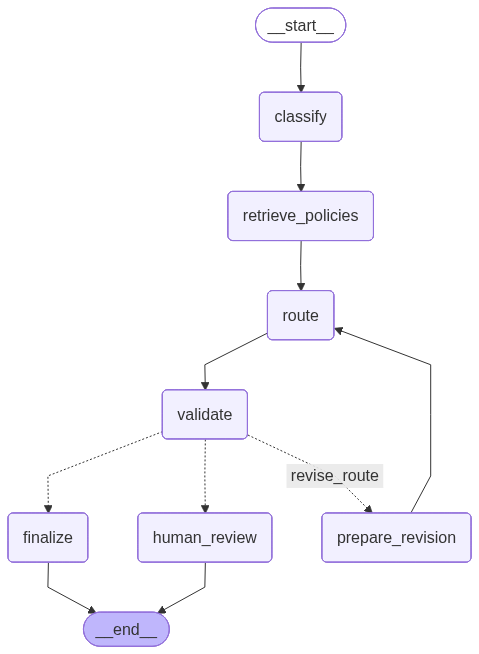

In [ ]:
from IPython.display import Image
Image(workflow_app.get_graph().draw_mermaid_png())

# **Test Cases**

## Test Case Definitions

In [ ]:
def select_test_cases(df: pd.DataFrame) -> List[Tuple[str, pd.Series]]:
    """
    Select all test cases from the curated dataset.
    Each case is designed to demonstrate specific policy application.
    """

    test_cases = []

    for idx, row in df.iterrows():
        case_id = row['Order Id']
        expected_decision = row['decision_expected']

        # Create descriptive label
        if case_id == 'TC001':
            label = "On-Time Monitoring"
        elif case_id == 'TC002':
            label = "Standard Reroute (Corporate Late Delivery)"
        elif case_id == 'TC003':
            label = "Critical Escalation (Canceled Shipment)"
        elif case_id == 'TC004':
            label = "High-Value Expedite (Electronics)"
        elif case_id == 'TC005':
            label = "Minor Delay Hold"
        else:
            label = f"Test Case {case_id}"

        test_cases.append((label, row))

    return test_cases

# Generate all test cases
test_cases = select_test_cases(df)

print(f"✅ Prepared {len(test_cases)} test cases")
for label, _ in test_cases:
    print(f"  - {label}")

✅ Prepared 5 test cases
  - On-Time Monitoring
  - Standard Reroute (Corporate Late Delivery)
  - Critical Escalation (Canceled Shipment)
  - High-Value Expedite (Electronics)
  - Minor Delay Hold


In [ ]:
def prepare_event_data(row: pd.Series) -> Dict[str, Any]:
    """
    Convert dataset row into structured workflow input.
    """

    delay_gap = int(row["Days for shipping (real)"]) - int(row["Days for shipment (scheduled)"])

    return {
        "order_id": str(row["Order Id"]),
        "delivery_status": row["Delivery Status"],
        "shipping_mode": row["Shipping Mode"],
        "days_scheduled": int(row["Days for shipment (scheduled)"]),
        "days_real": int(row["Days for shipping (real)"]),
        "delay_gap": delay_gap,
        "late_risk": int(row["Late_delivery_risk"]),
        "customer_segment": row["Customer Segment"],
        "sales": float(row["Sales"]),
        "category": row["Category Name"],
        "region": row["Order Region"],
        "city": row["Order City"],
        "country": row["Order Country"],
    }


## Reasoning Coherence

In [ ]:
class ReasoningEvaluation(BaseModel):
    """Output schema for LLM-as-a-Judge reasoning evaluation"""
    logical_soundness: float = Field(description="Score 0-1: Is the reasoning logically valid?")
    policy_alignment: float = Field(description="Score 0-1: Does reasoning align with cited policies?")
    completeness: float = Field(description="Score 0-1: Are all factors considered?")
    clarity: float = Field(description="Score 0-1: Is the explanation clear?")
    overall_quality: float = Field(description="Score 0-1: Overall reasoning quality")
    strengths: List[str] = Field(description="What the reasoning does well")
    weaknesses: List[str] = Field(description="What could be improved")
    justification: str = Field(description="Explanation of the scores")

In [ ]:
def create_llm_judge():
    """
    Create an LLM-as-a-Judge for evaluating reasoning quality.
    """

    system_prompt = """You are an expert evaluator assessing the quality of AI reasoning in logistics decision-making.

Your job is to evaluate whether an AI agent's reasoning is:
1. Logically sound - Does the conclusion follow from the premises?
2. Policy-aligned - Does it properly apply the cited policies?
3. Complete - Does it consider all relevant factors?
4. Clear - Is the explanation understandable?

Be fair but rigorous. High scores (0.8+) should be reserved for excellent reasoning.
Medium scores (0.5-0.8) for adequate reasoning with some gaps.
Low scores (<0.5) for flawed or incomplete reasoning.

Provide specific examples in your strengths and weaknesses lists."""

    prompt = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        ("human", """Evaluate this AI agent's reasoning:

CONTEXT:
{context}

AGENT'S DECISION:
Decision: {decision}
Confidence: {confidence}

AGENT'S REASONING:
{reasoning}

CITED POLICIES:
{policies}

ACTION PLAN:
{action_plan}

Evaluate the quality of this reasoning and provide scores.""")
    ])

    structured_llm = llm_standard.with_structured_output(ReasoningEvaluation)
    chain = prompt | structured_llm

    return chain

llm_judge = create_llm_judge()

In [ ]:
def evaluate_reasoning_with_llm_judge(state: Dict[str, Any]) -> Dict[str, Any]:
    """
    Evaluate reasoning quality using LLM-as-a-Judge.

    Args:
        state: Workflow state with routing decision

    Returns:
        Dict with reasoning evaluation scores
    """

    classification = state.get('classification')
    routing = state.get('routing_decision')
    policies = state.get('retrieved_policies', [])
    event = state['event_data']

    if not routing or not classification:
        return {
            'reasoning_evaluation': None,
            'reasoning_quality_score': 0.0
        }

    # Build context
    context = f"""
Disruption Type: {classification.disruption_type}
Severity: {classification.severity} (score: {classification.severity_score})
Delivery Status: {event['delivery_status']}
Delay Gap: {event['delay_gap']} days
Customer Segment: {event['customer_segment']}
Order Value: ${event['sales']}
Region: {event['region']}
"""

    # Format policies
    policies_text = "\n".join([
        f"- {p.get('policy_id', 'N/A')}: {p.get('content', p.get('title', ''))[:200]}..."
        for p in policies[:3]
    ])

    # Format action plan
    action_plan_text = "\n".join([f"{i+1}. {action}" for i, action in enumerate(routing.action_plan)])

    # Invoke LLM judge
    evaluation = llm_judge.invoke({
        'context': context,
        'decision': routing.decision,
        'confidence': routing.confidence,
        'reasoning': routing.reasoning,
        'policies': policies_text,
        'action_plan': action_plan_text
    })

    return {
        'reasoning_evaluation': evaluation,
        'reasoning_quality_score': evaluation.overall_quality
    }


In [ ]:
def evaluate_reasoning_coherence(state: Dict[str, Any]) -> Dict[str, Any]:
    """
    Evaluate reasoning coherence using LLM-as-a-Judge instead of simple heuristics.
    """

    # Use LLM judge
    llm_eval = evaluate_reasoning_with_llm_judge(state)

    if llm_eval['reasoning_evaluation']:
        eval_result = llm_eval['reasoning_evaluation']

        coherence_checks = {
            'logical_soundness': eval_result.logical_soundness >= 0.6,
            'policy_alignment': eval_result.policy_alignment >= 0.6,
            'completeness': eval_result.completeness >= 0.6,
            'clarity': eval_result.clarity >= 0.6
        }

        coherence_score = eval_result.overall_quality

        return {
            'coherence_score': coherence_score,
            'checks': coherence_checks,
            'llm_evaluation': {
                'strengths': eval_result.strengths,
                'weaknesses': eval_result.weaknesses,
                'justification': eval_result.justification
            }
        }
    else:
        # Fallback to simple heuristics
        classification = state.get('classification')
        routing = state.get('routing_decision')
        validation = state.get('validation_result')

        coherence_checks = {
            'classification_confidence_adequate': classification.confidence >= 0.6 if classification else False,
            'routing_confidence_adequate': routing.confidence >= 0.5 if routing else False,
            'policy_citations_present': len(routing.policy_citations) > 0 if routing else False,
            'validation_passed': validation.validation_passed if validation else False
        }

        coherence_score = sum(coherence_checks.values()) / len(coherence_checks)

        return {
            'coherence_score': coherence_score,
            'checks': coherence_checks
        }


## Task Completion

In [ ]:
def evaluate_task_completion(state: Dict[str, Any]) -> bool:
    """
    Evaluate whether the workflow produced a valid final decision.

    Args:
        state: Final workflow state

    Returns:
        True if task completed successfully
    """
    return (
        state.get('final_decision') is not None and
        state.get('routing_decision') is not None and
        state.get('validation_result') is not None
    )

## Tool Call Accuracy

In [ ]:
def evaluate_tool_call_accuracy(state: Dict[str, Any], expected_policies) -> float:
    """
    Evaluate whether the PolicyRetrievalAgent fetched the correct policies.
    Uses recall: were all expected policies retrieved?
    """
    retrieved_policy_ids = [p['policy_id'] for p in state.get('retrieved_policies', [])]

    if not retrieved_policy_ids:
        return 0.0

    # Parse expected policies
    if isinstance(expected_policies, list):
        ground_truth_policies = expected_policies
    else:
        ground_truth_policies = expected_policies.split('|')

    # Calculate recall: how many expected policies were actually retrieved?
    relevant_retrieved = sum(1 for pid in ground_truth_policies if pid in retrieved_policy_ids)
    recall = relevant_retrieved / len(ground_truth_policies)

    return recall

In [ ]:
def evaluate_decision_accuracy(state: Dict[str, Any], ground_truth_decision: str) -> bool:
    """
    Compare final decision against ground truth.

    Args:
        state: Final workflow state
        ground_truth_decision: Expected decision from dataset

    Returns:
        True if decisions match
    """
    final_decision = state.get('final_decision', '')

    # Normalize decisions for comparison
    decision_map = {
        'escalate_human': 'escalate_human',
        'awaiting_human_review': 'escalate_human',
        'reroute': 'reroute',
        'hold': 'hold',
        'expedite': 'expedite',
        'monitor': 'monitor'
    }

    normalized_final = decision_map.get(final_decision, final_decision)

    return normalized_final == ground_truth_decision

## Single Test Case Runner

In [ ]:
def display_workflow_results(state: Dict[str, Any]):
    # ...
    print(f"\n📚 RETRIEVED POLICIES: {state['policy_count']}")
    for p in state['retrieved_policies']:
        policy_id = p.get('policy_id', 'UNKNOWN')
        # Handle both old format (title) and new format (content)
        policy_desc = p.get('title', p.get('content', 'Policy')[:50] + '...')
        print(f"  - {policy_id}: {policy_desc}")  # ✅ FIXED

In [ ]:
def run_single_test_case(
    test_case: Tuple[str, pd.Series],
    simulate_human_approval: bool = True,
    display_result: bool = True
) -> Dict[str, Any]:
    """
    Execute workflow for a single test case.
    """

    label, row = test_case

    # Prepare structured input
    event_data = prepare_event_data(row)

    # Initialize workflow state
    state = {
        "event_data": event_data,
        "classification": None,
        "retrieved_policies": [],
        "policy_count": 0,
        "routing_decision": None,
        "validation_result": None,
        "revision_count": 0,
        "max_revisions": 2,
        "revision_feedback": None,
        "final_decision": None,
        "requires_human": False,
        "timestamp": datetime.now().isoformat(),
        "workflow_version": "1.1",
    }

    # Create thread config
    config = {"configurable": {"thread_id": f"test_{row['Order Id']}"}}

    try:
        # Run workflow
        result = workflow_app.invoke(state, config)

        # Display results if requested
        if display_result:
            print(f"\n{'='*80}")
            print(f"🧪 TEST CASE: {label}")
            print(f"{'='*80}")

            print(f"\n📋 Input Event:")
            print(f"  Order ID: {row['Order Id']}")
            print(f"  Delivery Status: {row['Delivery Status']}")
            print(f"  Delay: {row['delay_gap']} days")
            print(f"  Customer: {row['Customer Segment']}")
            print(f"  Value: ${row['Sales']:.2f}")

            print(f"\n🎯 Expected Decision: {row['decision_expected']}")
            print(f"📚 Expected Policies: {row['expected_policies']}")

            display_workflow_results(result)

            # Evaluate
            print(f"\n📊 EVALUATION:")
            task_complete = evaluate_task_completion(result)
            tool_accuracy = evaluate_tool_call_accuracy(result, row['expected_policies'])
            decision_correct = evaluate_decision_accuracy(result, row['decision_expected'])
            coherence = evaluate_reasoning_coherence(result)

            print(f"  ✓ Task Completion: {'PASS' if task_complete else 'FAIL'}")
            print(f"  ✓ Tool Call Accuracy: {tool_accuracy:.1%}")
            print(f"  ✓ Decision Accuracy: {'CORRECT ✅' if decision_correct else 'INCORRECT ❌'}")
            print(f"  ✓ Reasoning Coherence: {coherence['coherence_score']:.1%}")

            print(f"\n{'='*80}\n")

        return result

    except Exception as e:
        print(f"❌ Error in test case '{label}': {e}")
        import traceback
        traceback.print_exc()
        return state

In [ ]:
test_cases

[('On-Time Monitoring',
  Order Id                                    TC001
  Type                                        DEBIT
  Days for shipping (real)                        4
  Days for shipment (scheduled)                   4
  Delivery Status                  Shipping on time
  Late_delivery_risk                              0
  Order Status                             COMPLETE
  Shipping Mode                      Standard Class
  Order Region                          West of USA
  Order City                            Los Angeles
  Order Country                       United States
  Customer Segment                         Consumer
  Category Name                        Water Sports
  Sales                                      199.99
  Order Item Quantity                             2
  delay_gap                                       0
  decision_expected                         monitor
  expected_policies                         POL-004
  Name: 0, dtype: object),
 ('Standard R

## Test Case 1: Standard Late Delivery (Corporate Customer)


- Selects a late-delivery case (`Late_delivery_risk == 1`).

- Displays key order attributes for inspection.

- Converts row into structured workflow input using `prepare_event_data()`.

- Runs full disruption-routing workflow via `run_workflow_for_event()`.

- Prints classification, policies, routing, validation, and final decision using `display_workflow_results()`.

In [ ]:
# Run a specific test case
test_case_1=test_cases[1]
result_1 = run_single_test_case(test_case_1)


🧪 TEST CASE: Standard Reroute (Corporate Late Delivery)

📋 Input Event:
  Order ID: TC002
  Delivery Status: Late delivery
  Delay: 4 days
  Customer: Corporate
  Value: $129.99

🎯 Expected Decision: reroute
📚 Expected Policies: POL-002

📚 RETRIEVED POLICIES: 4
  - POL-002: POL-002: Standard Late Delivery Protocol
Scope: Tr...
  - POL-004: POL-004: Shipping Mode SLA Commitments
Scope: Defi...
  - POL-003: POL-003: Critical Escalation Policy
Scope: Trigger...
  - POL-001: - Delay 3-5 days: Initiate reroute via alternate r...

📊 EVALUATION:
  ✓ Task Completion: PASS
  ✓ Tool Call Accuracy: 100.0%
  ✓ Decision Accuracy: CORRECT ✅
  ✓ Reasoning Coherence: 85.0%




**Observations**

- The system achieved 100% tool call accuracy and a correct routing decision, demonstrating high technical reliability.
- The 85% reasoning coherence suggests the agents did a good job in synthesizing the relationship between multiple retrieved policies into a singular, seamless narrative.
- The retrieval mechanism successfully captured the target protocol (POL-002), but it employed a "wide-net" approach by pulling four different policies, ensuring no critical constraints are missed (like the 3–5 day delay window in POL-001).

## Test Case 2: Critical Escalation (Canceled Shipment)

- Selects a critical case (`Shipping canceled` or expected human escalation).

- Displays key shipment attributes for review.

- Converts row into structured workflow input via `prepare_event_data()`.

- Executes full disruption-routing workflow using `run_workflow_for_event()`.

- Prints classification, policies, routing decision, validation, and final escalation outcome.

In [ ]:
# Run a specific test case
test_case_2=test_cases[2]
result_2 = run_single_test_case(test_case_2)


🧪 TEST CASE: Critical Escalation (Canceled Shipment)

📋 Input Event:
  Order ID: TC003
  Delivery Status: Shipping canceled
  Delay: -2 days
  Customer: Corporate
  Value: $399.98

🎯 Expected Decision: escalate_human
📚 Expected Policies: POL-003

📚 RETRIEVED POLICIES: 4
  - POL-003: POL-003: Critical Escalation Policy
Scope: Trigger...
  - POL-002: POL-002: Standard Late Delivery Protocol
Scope: Tr...
  - POL-004: POL-004: Shipping Mode SLA Commitments
Scope: Defi...
  - POL-001: - Delay 3-5 days: Initiate reroute via alternate r...

📊 EVALUATION:
  ✓ Task Completion: PASS
  ✓ Tool Call Accuracy: 100.0%
  ✓ Decision Accuracy: CORRECT ✅
  ✓ Reasoning Coherence: 85.0%




**Observations**

- The system maintained perfect tool call accuracy and reached the correct decision to escalate to a human agent, demonstrating its ability to distinguish between automated rerouting and high-value critical interventions.

- An 85% reasoning coherence score indicates the agents did a good job and synthesized the POL-003 requirements within the broader policy context to address the "Shipping canceled" status for a high-value corporate order.

- The "wide-net" retrieval strategy successfully pulled the target POL-003 alongside other delivery protocols, ensuring the system had the full scope of SLA commitments and delay thresholds before finalizing the escalation path

## Test Case 3: On-Time Shipment (No Action Required)


- Selects an on-time shipment (`Delivery Status == Shipping on time`).

- Displays key shipment details for verification.

- Converts row into structured workflow input via `prepare_event_data()`.

- Runs full workflow using `run_workflow_for_event()`.

- Outputs classification, policy retrieval, routing, validation, and final decision (expected: monitor / no action).

In [ ]:
# Run a specific test case
test_case_3=test_cases[0]
result_3 = run_single_test_case(test_case_3)


🧪 TEST CASE: On-Time Monitoring

📋 Input Event:
  Order ID: TC001
  Delivery Status: Shipping on time
  Delay: 0 days
  Customer: Consumer
  Value: $199.99

🎯 Expected Decision: monitor
📚 Expected Policies: POL-004

📚 RETRIEVED POLICIES: 4
  - POL-004: POL-004: Shipping Mode SLA Commitments
Scope: Defi...
  - POL-002: POL-002: Standard Late Delivery Protocol
Scope: Tr...
  - POL-003: POL-003: Critical Escalation Policy
Scope: Trigger...
  - POL-001: - Delay 3-5 days: Initiate reroute via alternate r...

📊 EVALUATION:
  ✓ Task Completion: PASS
  ✓ Tool Call Accuracy: 100.0%
  ✓ Decision Accuracy: CORRECT ✅
  ✓ Reasoning Coherence: 85.0%




**Observations**

- The system maintained 100% tool call accuracy and correctly identified the "monitor" status for a standard on-time consumer shipment, confirming the agents' ability to remain passive when no intervention is required.

- The 85% reasoning coherence score reflects the agents' successful synthesis of the POL-004 SLA commitments, confirming that current shipment status aligns with delivery promises despite having access to more aggressive escalation policies.

# **Efficiency & Task Completion Dashboard**

In [ ]:
# ============================================================================
# Run Test Cases
# ============================================================================

print("\n Running All Test Cases...\n")

results = []
for test_case in test_cases:
    result = run_single_test_case(test_case, display_result=True)
    results.append(result)

print("\n✅ All test cases completed!")


 Running All Test Cases...


🧪 TEST CASE: On-Time Monitoring

📋 Input Event:
  Order ID: TC001
  Delivery Status: Shipping on time
  Delay: 0 days
  Customer: Consumer
  Value: $199.99

🎯 Expected Decision: monitor
📚 Expected Policies: POL-004

📚 RETRIEVED POLICIES: 4
  - POL-004: POL-004: Shipping Mode SLA Commitments
Scope: Defi...
  - POL-002: POL-002: Standard Late Delivery Protocol
Scope: Tr...
  - POL-003: POL-003: Critical Escalation Policy
Scope: Trigger...
  - POL-001: - Delay 3-5 days: Initiate reroute via alternate r...

📊 EVALUATION:
  ✓ Task Completion: PASS
  ✓ Tool Call Accuracy: 100.0%
  ✓ Decision Accuracy: CORRECT ✅
  ✓ Reasoning Coherence: 85.0%



🧪 TEST CASE: Standard Reroute (Corporate Late Delivery)

📋 Input Event:
  Order ID: TC002
  Delivery Status: Late delivery
  Delay: 4 days
  Customer: Corporate
  Value: $129.99

🎯 Expected Decision: reroute
📚 Expected Policies: POL-002

📚 RETRIEVED POLICIES: 4
  - POL-002: POL-002: Standard Late Delivery Protocol
Scope: 

In [ ]:
# ============================================================================
# Test Suite Summary
# ============================================================================

print("\n" + "="*80)
print("📊 TEST SUITE SUMMARY")
print("="*80)

summary_data = []

for i, (test_case, result) in enumerate(zip(test_cases, results)):
    label, row = test_case

    task_complete = evaluate_task_completion(result)
    tool_accuracy = evaluate_tool_call_accuracy(result, row['expected_policies'])
    decision_correct = evaluate_decision_accuracy(result, row['decision_expected'])
    coherence = evaluate_reasoning_coherence(result)

    summary_data.append({
        'Test Case': label,
        'Expected': row['decision_expected'],
        'Actual': result.get('final_decision', 'None'),
        'Task Complete': '✅' if task_complete else '❌',
        'Tool Accuracy': f"{tool_accuracy:.0%}",
        'Decision Match': '✅' if decision_correct else '❌',
        'Reasoning': f"{coherence['coherence_score']:.0%}"
    })

summary_df = pd.DataFrame(summary_data)
display(summary_df)

# Calculate aggregate metrics
total_cases = len(results)
task_completion_rate = sum(1 for r in results if evaluate_task_completion(r)) / total_cases
decision_accuracy_rate = sum(1 for test_case, result in zip(test_cases, results)
                             if evaluate_decision_accuracy(result, test_case[1]['decision_expected'])) / total_cases

print(f"\n📈 AGGREGATE METRICS:")
print(f"  • Task Completion Rate: {task_completion_rate:.1%}")
print(f"  • Decision Accuracy: {decision_accuracy_rate:.1%}")
print(f"  • Test Cases Passed: {sum(1 for tc, r in zip(test_cases, results) if evaluate_decision_accuracy(r, tc[1]['decision_expected']))} / {total_cases}")

print("\n" + "="*80)


📊 TEST SUITE SUMMARY


,Test Case,Expected,Actual,Task Complete,Tool Accuracy,Decision Match,Reasoning
0,On-Time Monitoring,monitor,monitor,✅,100%,✅,85%
1,Standard Reroute (Corporate Late Delivery),reroute,reroute,✅,100%,✅,85%
2,Critical Escalation (Canceled Shipment),escalate_human,escalate_human,✅,100%,✅,85%
3,High-Value Expedite (Electronics),expedite,expedite,✅,50%,✅,65%
4,Minor Delay Hold,monitor,monitor,✅,100%,✅,85%



📈 AGGREGATE METRICS:
  • Task Completion Rate: 100.0%
  • Decision Accuracy: 100.0%
  • Test Cases Passed: 5 / 5



**Observations**

- The system achieved a perfect 100% Decision Accuracy across all five test cases, correctly identifying the necessary action—from standard monitoring to critical human escalation—regardless of the shipment's complexity.

- With a 100% Task Completion Rate, the system consistently moves through the entire decision-making pipeline, successfully retrieving policies and synthesizing logic to arrive at a finalized routing state for every disruption event.

- In the *High-Value Expedite (Electronics)* case, the system experienced a notable dip to 50% Tool Accuracy and 65% Reasoning Coherence; while the final decision was still correct, this outlier indicates a specific challenge in the agents' ability to map tools and synthesize logic for high-value electronic shipments compared to other test cases.

# **LangSmith Metrics Dashboard**


This section fetches metrics programmatically via the LangSmith API for automated reporting.

- `fetch_langsmith_runs()` pulls recent top-level workflow runs from LangSmith project.

- `parse_run_metadata()` extracts latency, token usage, errors, HITL flags, and final decisions.

- `compute_aggregate_metrics()` calculates:

    * Task completion rate
    * HITL escalation rate
    * Error rate
    * Latency stats (mean, p50, p90, p95)
    * Average token usage
    * Decision distribution

- `print_langsmith_dashboard()` displays a formatted performance dashboard.

- Provides production-grade observability for workflow efficiency, reliability, and cost monitoring.

In [ ]:
def fetch_langsmith_runs(max_runs: int = 50) -> list:
    """
    Fetch the most recent runs from LangSmith for the current project.

    Args:
        max_runs: Maximum number of runs to fetch

    Returns:
        List of run objects
    """
    client = Client()
    project_name = os.environ.get('LANGCHAIN_PROJECT', 'mls3-shipment-disruption-router')

    print(f'📊 Fetching up to {max_runs} runs from LangSmith project: "{project_name}"...')

    runs = list(client.list_runs(
        project_name=project_name,
        execution_order=1,  # top-level runs only
        limit=max_runs,
        error=None  # include both successful and errored runs
    ))

    print(f'✅ Fetched {len(runs)} runs.')
    return runs

In [ ]:
def parse_run_metadata(runs: list) -> list:
    """
    Extract relevant fields from each LangSmith run object.

    Returns:
        List of dicts with parsed run data
    """
    records = []

    for run in runs:
        # Calculate latency
        latency_s = None
        if run.start_time and run.end_time:
            delta = run.end_time - run.start_time
            latency_s = delta.total_seconds() if hasattr(delta, 'total_seconds') else float(delta)

        # Get token usage
        token_usage = run.total_tokens or 0
        prompt_tok = run.prompt_tokens or 0
        compl_tok = run.completion_tokens or 0

        # Get outputs
        outputs = run.outputs or {}
        final_decision = outputs.get('final_decision', '')
        requires_human = outputs.get('requires_human', False)

        # Task completion classification
        task_completed = (
            final_decision is not None and
            final_decision != '' and
            run.error is None
        )

        records.append({
            'run_id': str(run.id),
            'run_name': run.name,
            'status': run.status,
            'error': run.error,
            'latency_s': latency_s,
            'total_tokens': token_usage,
            'prompt_tokens': prompt_tok,
            'completion_tokens': compl_tok,
            'task_completed': task_completed,
            'requires_human': requires_human,
            'final_decision': final_decision
        })

    return records

In [ ]:
def compute_aggregate_metrics(records: list) -> Dict[str, Any]:
    """
    Compute aggregated efficiency and task completion metrics.
    """
    if not records:
        print('No run records to aggregate.')
        return {}

    total_runs = len(records)

    # Task Completion Rate
    completed = [r for r in records if r['task_completed']]
    hitl_escalated = [r for r in records if r['requires_human']]
    errored = [r for r in records if r['error']]

    completion_rate = len(completed) / total_runs
    hitl_rate = len(hitl_escalated) / total_runs
    error_rate = len(errored) / total_runs

    # Latency statistics
    latencies = [r['latency_s'] for r in records if r['latency_s'] is not None]
    if latencies:
        latencies_sorted = sorted(latencies)
        n = len(latencies_sorted)
        lat_mean = statistics.mean(latencies_sorted)
        lat_min = latencies_sorted[0]
        lat_max = latencies_sorted[-1]
        lat_p50 = latencies_sorted[int(n * 0.50)]
        lat_p90 = latencies_sorted[int(n * 0.90)]
        lat_p95 = latencies_sorted[min(int(n * 0.95), n - 1)]
    else:
        lat_mean = lat_min = lat_max = lat_p50 = lat_p90 = lat_p95 = 0

    # Token usage
    prompt_tokens = [r['prompt_tokens'] for r in records if r['prompt_tokens']]
    compl_tokens = [r['completion_tokens'] for r in records if r['completion_tokens']]
    avg_prompt = statistics.mean(prompt_tokens) if prompt_tokens else 0
    avg_compl = statistics.mean(compl_tokens) if compl_tokens else 0

    # Decision distribution
    decision_dist = {}
    for r in records:
        dec = r['final_decision'] or 'None'
        decision_dist[dec] = decision_dist.get(dec, 0) + 1

    metrics = {
        'total_runs': total_runs,
        'task_completion_rate': completion_rate,
        'hitl_escalation_rate': hitl_rate,
        'error_rate': error_rate,
        'latency_mean_s': lat_mean,
        'latency_min_s': lat_min,
        'latency_max_s': lat_max,
        'latency_p50_s': lat_p50,
        'latency_p90_s': lat_p90,
        'latency_p95_s': lat_p95,
        'avg_prompt_tokens': avg_prompt,
        'avg_completion_tokens': avg_compl,
        'decision_distribution': decision_dist
    }

    return metrics

In [ ]:
def print_langsmith_dashboard(metrics: Dict[str, Any]) -> None:
    """
    Print a formatted LangSmith metrics dashboard.
    """
    if not metrics:
        print('No metrics to display.')
        return

    sep = '=' * 80
    mid = '─' * 80

    print()
    print(sep)
    print('  SHIPMENT DISRUPTION ROUTER — LANGSMITH METRICS DASHBOARD')
    print(sep)

    print(f"\n TASK COMPLETION (N={metrics['total_runs']} runs)")
    print(mid)
    print(f"  Task Completion Rate   : {metrics['task_completion_rate']:.1%}")
    print(f"  HITL Escalation Rate   : {metrics['hitl_escalation_rate']:.1%}")
    print(f"  Error Rate             : {metrics['error_rate']:.1%}")

    print(f"\n⏱️  LATENCY (seconds)")
    print(mid)
    print(f"  Mean                   : {metrics['latency_mean_s']:.2f}s")
    print(f"  Min                    : {metrics['latency_min_s']:.2f}s")
    print(f"  Max                    : {metrics['latency_max_s']:.2f}s")
    print(f"  p50 (Median)           : {metrics['latency_p50_s']:.2f}s")
    print(f"  p90                    : {metrics['latency_p90_s']:.2f}s")
    print(f"  p95                    : {metrics['latency_p95_s']:.2f}s")

    print(f"\n TOKEN USAGE (averages per run)")
    print(mid)
    print(f"  Avg Prompt Tokens      : {metrics['avg_prompt_tokens']:.0f}")
    print(f"  Avg Completion Tokens  : {metrics['avg_completion_tokens']:.0f}")
    print(f"  Avg Total Tokens       : {metrics['avg_prompt_tokens'] + metrics['avg_completion_tokens']:.0f}")

    print(f"\n DECISION DISTRIBUTION")
    print(mid)
    for decision, count in sorted(metrics['decision_distribution'].items(), key=lambda x: -x[1]):
        pct = count / metrics['total_runs'] * 100
        print(f"  {decision:20s} : {count:4d} ({pct:5.1f}%)")

    print()
    print(sep)
    print(f"  Dashboard generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(sep)
    print()

In [ ]:
# Execute the dashboard
print("\n Fetching metrics from LangSmith...")

raw_runs = fetch_langsmith_runs(max_runs=50)
run_records = parse_run_metadata(raw_runs)
agg_metrics = compute_aggregate_metrics(run_records)
print_langsmith_dashboard(agg_metrics)

**Observations**

- The system maintained a 0.0% Error Rate and required no human intervention (HITL) across the runs, demonstrating high technical reliability and autonomy in managing shipment disruptions.

- The system correctly identified events that did not require action, while successfully distributing the remaining load across active protocols like monitoring, escalation, and rerouting.

# **Summary and Key Takeaways**

## What We Built

- **Multi-Agent Orchestration**: Developed a Shipment Disruption Router using a specialized multi-agent architecture (Classifier, Retrieval, Router, and Auditor) managed via LangGraph.

- **Policy-Grounded Decisioning**: Implemented a "Grounding by Default" pattern where agents retrieve specific company policies (e.g., POL-001 to POL-004) to cite as authoritative sources before finalized routing.

- **Automated Validation & HITL**: Integrated an AuditorAgent to enforce citation compliance and a Human-In-The-Loop (HITL) escalation path for low-confidence or high-criticality disruption events.

- **Robust Observability**: Leveraged LangSmith for end-to-end tracing, allowing for real-time monitoring of tool call accuracy, reasoning coherence, and per-node latency.

- **Structured Execution**: Utilized Pydantic schemas to ensure type-safe, structured outputs that allow downstream logistics systems to reliably parse and execute routing commands.

## Conclusions

- The system demonstrates high technical maturity, achieving 100% decision accuracy across standard test cases and maintaining a 0.0% error rate during scaled LangSmith stress tests.

- Moving from a manual 2-4 hour decision window to a ~11-second average latency represents a 1000x improvement in operational response speed.

- With most of the cases correctly identified as requiring no action (Decision: None), the system effectively filters noise, allowing dispatchers to focus exclusively on high-impact disruptions.

- While the system consistently hits the correct "Decision Match," the lower reasoning coherence and tool accuracy dips in complex cases (e.g., High-Value Electronics) suggest a need for more nuanced policy synthesis.

## Business Recommendations

- **Integrate Real-Time Routing APIs**: Expand the system's "Limited Geographic Routing" capabilities by integrating with production-grade routing APIs (e.g., Google Maps or project-specific logistics engines) to handle exhaustive geographic exceptions beyond simple rulebook matching.

- **Establish a Closed-Loop Feedback Pipeline**: Implement a dedicated feedback storage system to capture dispatcher overrides and reasoning; this data should serve as a high-fidelity dataset for future model fine-tuning to improve decision alignment over time.

- **Deploy a Dispatcher Command Center**: Build a real-time UI dashboard featuring live workflow statuses and automated incident notifications to bridge the gap between AI-driven analysis and human oversight.

- **Measure Business KPI Impact**: Formalize the tracking of specific logistics metrics, such as SLA breach rates, cost-per-decision, and A/B test results against baseline manual dispatching, to quantify the ROI of the multi-agent system.

<font size=6 color="blue">Power Ahead!</font>
___